# Laboratorio 1 — Series de Tiempo
## Bloque 2: Análisis exploratorio de datos (Hugo)

CC3084 — Data Science, Semestre II 2026.

Este notebook realiza el análisis exploratorio (EDA) sobre la base ya limpia (`data/processed/base_limpia.csv`, producida por el bloque 1). Cubre:

a. comportamiento temporal del número de viajeros;
b. países con mayor cantidad de viajeros;
c. regiones con mayor cantidad de viajeros;
d. vías de ingreso y fronteras más utilizadas;
e. valores faltantes, duplicados y atípicos;
f. estadísticas descriptivas y visualizaciones con su interpretación.

El punto (f) es transversal: cada sección incluye sus estadísticas descriptivas, su visualización y la interpretación correspondiente. Convenciones del equipo: solo `matplotlib` (sin seaborn); las figuras se guardan en `informe/figuras/` a 150 dpi.

In [1]:
import sys
sys.path.append("../src")

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from series import FECHA_INICIO, FECHA_FIN, FECHA_FIN_TRAIN

RUTA_BASE = "../data/processed/base_limpia.csv"
RUTA_FIGURAS = "../informe/figuras"
os.makedirs(RUTA_FIGURAS, exist_ok=True)

df = pd.read_csv(RUTA_BASE, parse_dates=["fecha"])
print("Shape:", df.shape)
print("Rango:", df["fecha"].min().date(), "a", df["fecha"].max().date())
df.head()

Shape: (161036, 17)
Rango: 2009-01-01 a 2026-06-01


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha,Región dos_raw,País_raw,Regiones OMT_raw
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01,Europa,Albania,EUROPA MERIDIONAL
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01,Europa,Alemania,EUROPA OCCIDENTAL
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01,Otros Paises Del Mundo,Angola,ÁFRICA CENTRAL
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01,Oriente Medio,Arabia Saudita,ORIENTE MEDIO
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01,Otros Paises Del Mundo,Argelia,ÁFRICA DEL NORTE


## Panorama general y estadísticas descriptivas

Primero fijamos las magnitudes globales de la base y la distribución de la variable de conteo `Viajero` a nivel de fila. Esto da el marco para interpretar el resto del EDA.

In [2]:
total = df["Viajero"].sum()
print(f"Registros (filas): {len(df):,}")
print(f"Meses cubiertos:   {df['fecha'].nunique()}")
print(f"Total de viajeros: {total:,.0f}")
print(f"Variables categóricas de análisis: Vía, Frontera, País, Región dos, Regiones OMT, Tipo de Viajero")
print()
print("Distribución de 'Viajero' a nivel de fila:")
df["Viajero"].describe(percentiles=[.25, .5, .75, .9, .99]).round(2)

Registros (filas): 161,036
Meses cubiertos:   210
Total de viajeros: 52,287,937
Variables categóricas de análisis: Vía, Frontera, País, Región dos, Regiones OMT, Tipo de Viajero

Distribución de 'Viajero' a nivel de fila:


count    161036.00
mean        324.70
std        2387.75
min           0.00
25%           2.00
50%           7.00
75%          38.89
90%         260.00
99%        6113.92
max       92336.04
Name: Viajero, dtype: float64

**Interpretación.** La base agrega **52,287,937** viajeros repartidos en **161,036** filas y **210** meses (ene-2009 a jun-2026). A nivel de fila la variable `Viajero` está fuertemente sesgada a la derecha: la mediana es de apenas **7** viajeros por combinación mes/vía/frontera/país, pero la media es **~325** y el máximo llega a **92,336**. Es decir, muchísimas combinaciones pequeñas (países lejanos, meses concretos) y unas pocas combinaciones enormes (El Salvador por vía terrestre) que concentran el volumen. Esta asimetría condiciona todo el análisis y obliga a mirar la serie **agregada por mes**, no las filas sueltas.

## a. Comportamiento temporal del número de viajeros

Construimos la serie mensual total (suma de `Viajero` por mes) y la observamos a tres escalas: la serie mensual completa, los totales anuales y el patrón estacional intra-anual.

count       210.0
mean     248990.2
std      100744.5
min        9779.0
25%      184592.9
50%      250393.5
75%      315372.8
max      526190.0
Name: Viajero, dtype: float64


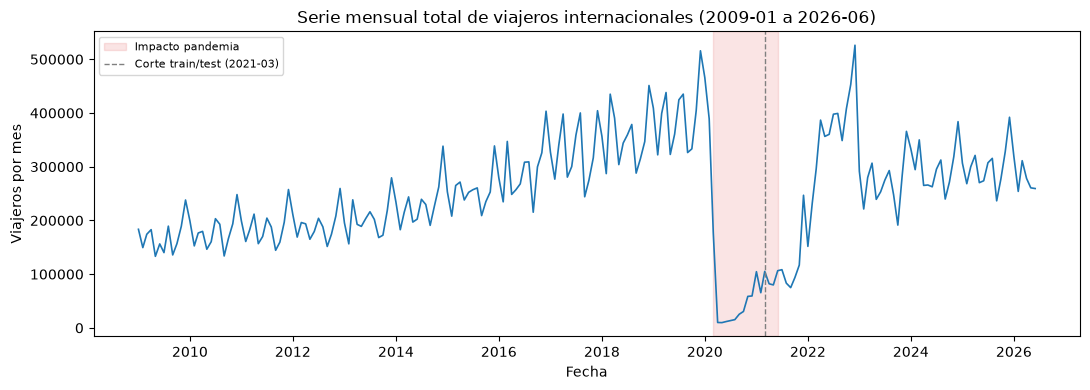

In [3]:
serie = df.groupby("fecha")["Viajero"].sum().sort_index()
print(serie.describe().round(1))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie.values, color="tab:blue", lw=1.2)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           color="tab:red", alpha=0.12, label="Impacto pandemia")
ax.axvline(pd.Timestamp(FECHA_FIN_TRAIN), color="gray", ls="--", lw=1,
           label="Corte train/test (2021-03)")
ax.set_title("Serie mensual total de viajeros internacionales (2009-01 a 2026-06)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros por mes")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_serie_temporal.png"), dpi=150)
plt.show()

**Interpretación.** La serie mensual promedia **~249,000** viajeros con una fuerte estacionalidad regular. Se distinguen tres regímenes: (1) crecimiento sostenido y estacional de 2009 a 2019; (2) el **colapso por la pandemia** desde marzo 2020, con el mínimo histórico en **abril 2020 (9,779 viajeros)**, cerca del 4% de un mes normal; y (3) la recuperación posterior a 2022, que retoma el nivel prepandemia. La línea punteada marca el corte train/test: la caída queda en entrenamiento y la recuperación en prueba, como se justificó en el bloque 1.

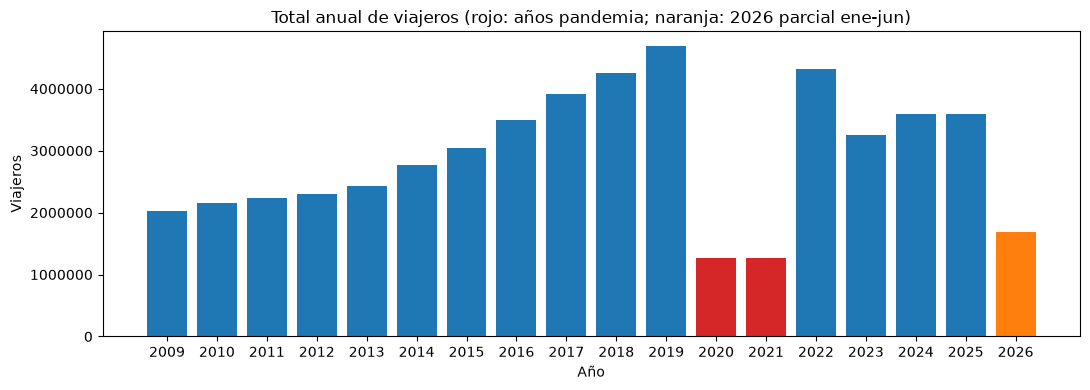

Año
2009    2028776.0
2010    2152899.0
2011    2231456.0
2012    2299816.0
2013    2432169.0
2014    2762602.0
2015    3041643.0
2016    3496217.0
2017    3921460.0
2018    4256349.0
2019    4691820.0
2020    1266340.0
2021    1267768.0
2022    4316164.0
2023    3248709.0
2024    3593876.0
2025    3597238.0
2026    1682636.0
Name: Viajero, dtype: float64

In [4]:
anual = df.groupby("Año")["Viajero"].sum()
colores = ["tab:red" if a in (2020, 2021) else ("tab:orange" if a == 2026 else "tab:blue")
           for a in anual.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(anual.index.astype(str), anual.values, color=colores)
ax.set_title("Total anual de viajeros (rojo: años pandemia; naranja: 2026 parcial ene-jun)")
ax.set_xlabel("Año")
ax.set_ylabel("Viajeros")
ax.ticklabel_format(axis="y", style="plain")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_totales_anuales.png"), dpi=150)
plt.show()
anual.round(0)

**Interpretación.** Los totales anuales confirman el crecimiento estructural: de **2.03M** en 2009 a **4.69M** en 2019 (máximo histórico). En 2020 y 2021 el volumen se desploma a **~1.27M** cada año (barras rojas). En 2022 hay un rebote fuerte y desde 2023 el nivel se estabiliza alrededor de 3.2M-3.6M, algo por debajo del pico de 2019 (en parte por el cambio metodológico de 2023 documentado en el bloque 1). **2026 (naranja) es parcial** (solo ene-jun) y no debe compararse con los años completos.

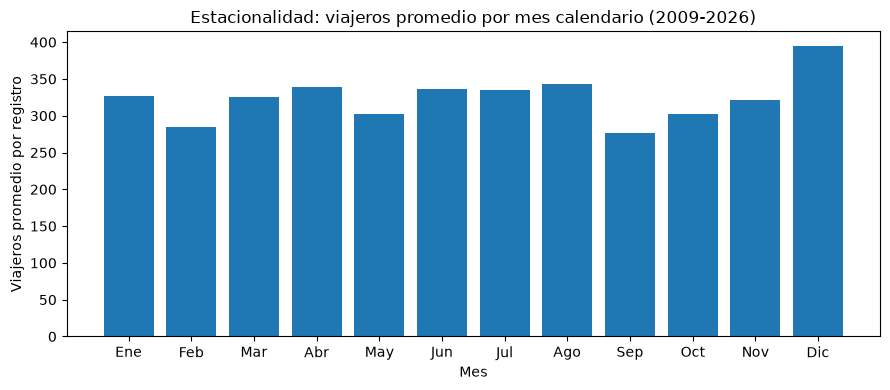

In [5]:
meses_nom = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
estacional = df.groupby("Mes cod")["Viajero"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([meses_nom[i - 1] for i in estacional.index], estacional.values, color="tab:blue")
ax.set_title("Estacionalidad: viajeros promedio por mes calendario (2009-2026)")
ax.set_xlabel("Mes")
ax.set_ylabel("Viajeros promedio por registro")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_estacionalidad.png"), dpi=150)
plt.show()

**Interpretación.** El patrón estacional es claro y estable: **diciembre y enero** son los meses más altos (temporada de fin de año y vacaciones), con un repunte secundario en **Semana Santa (marzo-abril)**. El punto más bajo del año es **septiembre**. Esta estacionalidad anual bien marcada es la señal más importante para el modelado posterior.

## b. Países con mayor cantidad de viajeros

Siguiendo la decisión del bloque 1, **Guatemala se excluye del ranking** (son residentes retornando, ~28% del total), pero se reporta aparte para dimensionar su peso.

Guatemala (excluida del ranking): 14,792,331 (28.3% del total)


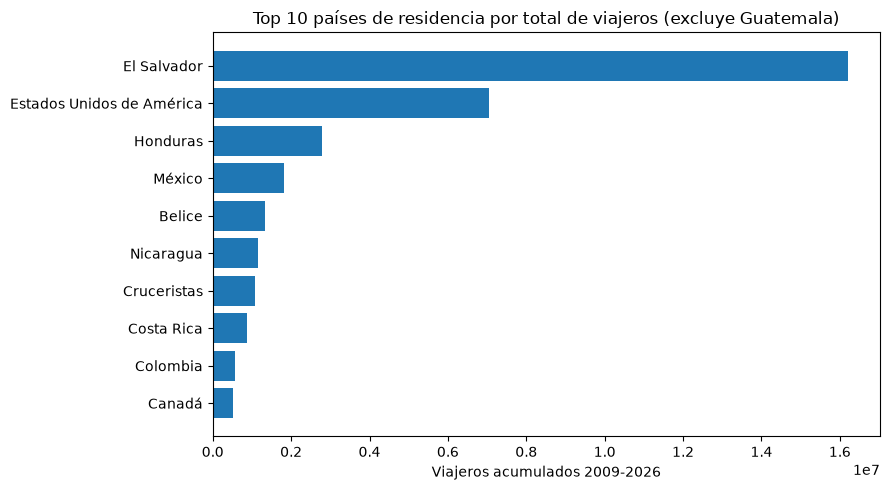

País
El Salvador                  16213975.0
Estados Unidos de América     7047843.0
Honduras                      2788233.0
México                        1808946.0
Belice                        1328256.0
Nicaragua                     1164343.0
Cruceristas                   1078372.0
Costa Rica                     882180.0
Colombia                       561035.0
Canadá                         526247.0
Name: Viajero, dtype: float64

In [6]:
gt = df.loc[df["País"] == "Guatemala", "Viajero"].sum()
print(f"Guatemala (excluida del ranking): {gt:,.0f} ({gt/total:.1%} del total)")

top_paises = (df[df["País"] != "Guatemala"]
              .groupby("País")["Viajero"].sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_paises.index[::-1], top_paises.values[::-1], color="tab:blue")
ax.set_title("Top 10 países de residencia por total de viajeros (excluye Guatemala)")
ax.set_xlabel("Viajeros acumulados 2009-2026")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_top_paises.png"), dpi=150)
plt.show()
top_paises.round(0)

**Interpretación.** El ranking está **dominado por los vecinos centroamericanos y Norteamérica**. **El Salvador** encabeza con **16.2M** (más del doble que el siguiente), seguido de **Estados Unidos (7.05M)** y **Honduras (2.79M)**. Luego aparecen México (1.81M), Belice, Nicaragua, Costa Rica y Colombia. El peso de El Salvador y Honduras refleja el intenso tráfico terrestre fronterizo, mientras que EE. UU. representa el principal mercado aéreo. Estos tres primeros son justamente las series por país que construye el bloque 1.

## c. Regiones con mayor cantidad de viajeros

Usamos `Región dos` (ya normalizada en el bloque 1) como agrupación principal y contrastamos con `Regiones OMT`.

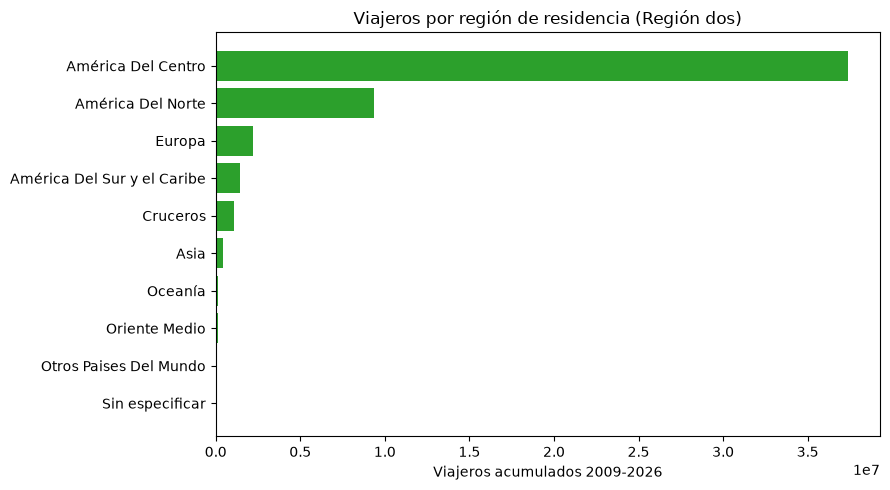

Región dos
América Del Centro             71.5 %
América Del Norte              17.9 %
Europa                          4.3 %
América Del Sur y el Caribe     2.8 %
Cruceros                        2.1 %
Asia                            0.8 %
Oceanía                         0.3 %
Oriente Medio                   0.3 %
Otros Paises Del Mundo          0.0 %
Sin especificar                 0.0 %
Name: Viajero, dtype: str


In [7]:
reg = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(reg.index[::-1], reg.values[::-1], color="tab:green")
ax.set_title("Viajeros por región de residencia (Región dos)")
ax.set_xlabel("Viajeros acumulados 2009-2026")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_regiones.png"), dpi=150)
plt.show()
print((reg / reg.sum()).mul(100).round(1).astype(str) + ' %')

**Interpretación.** La distribución regional es muy concentrada: **América del Centro** aporta **37.4M (~71%)** del total, seguida de lejos por **América del Norte (9.38M, ~18%)**. Europa (~2.2M), América del Sur y el Caribe (~1.4M) y Cruceros (~1.1M) completan el grueso; Asia, Oceanía y Oriente Medio son marginales. En síntesis, el turismo/ingreso a Guatemala es **fundamentalmente regional**: casi 9 de cada 10 viajeros provienen del continente americano.

## d. Vías de ingreso y fronteras más utilizadas

Analizamos la mezcla por vía de ingreso (Aérea/Terrestre/Marítima) y las fronteras concretas más transitadas.

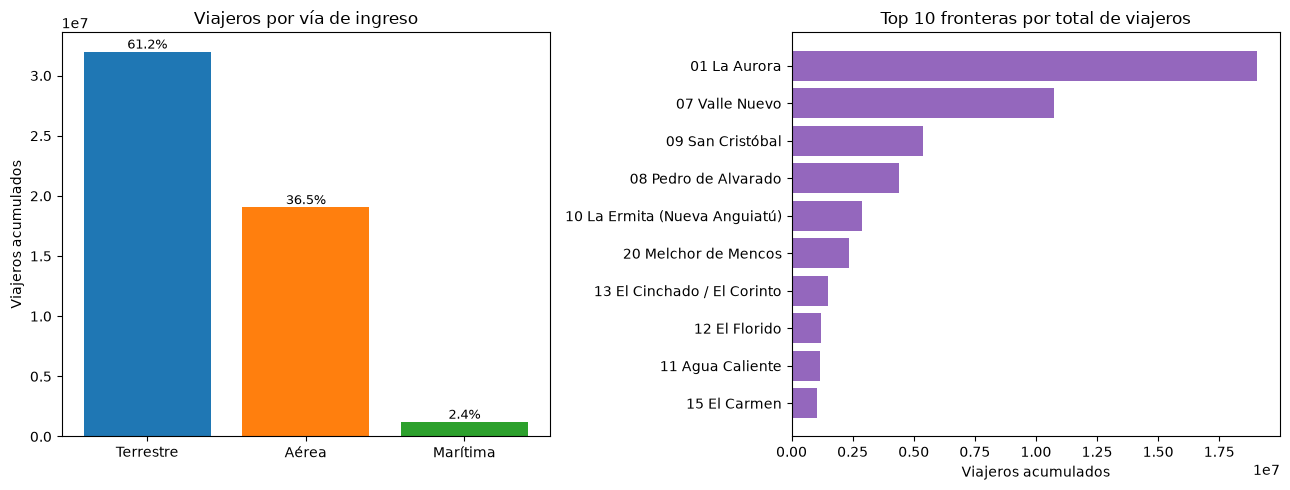

Vía
Terrestre    31995305.0
Aérea        19063850.0
Marítima      1228782.0
Name: Viajero, dtype: float64

Frontera
01 La Aurora                     19034395.0
07 Valle Nuevo                   10732340.0
09 San Cristóbal                  5363009.0
08 Pedro de Alvarado              4393577.0
10 La Ermita (Nueva Anguiatú)     2879210.0
20 Melchor de Mencos              2349551.0
13 El Cinchado / El Corinto       1497006.0
12 El Florido                     1221040.0
11 Agua Caliente                  1154542.0
15 El Carmen                      1023092.0
Name: Viajero, dtype: float64


In [8]:
via = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
front = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(via.index, via.values, color=["tab:blue", "tab:orange", "tab:green"])
axes[0].set_title("Viajeros por vía de ingreso")
axes[0].set_ylabel("Viajeros acumulados")
for i, v in enumerate(via.values):
    axes[0].text(i, v, f"{v/via.sum():.1%}", ha="center", va="bottom", fontsize=9)
axes[1].barh(front.index[::-1], front.values[::-1], color="tab:purple")
axes[1].set_title("Top 10 fronteras por total de viajeros")
axes[1].set_xlabel("Viajeros acumulados")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_vias_fronteras.png"), dpi=150)
plt.show()
print(via.round(0)); print(); print(front.round(0))

**Interpretación.** La vía **terrestre domina con 31.99M (~61%)**, seguida de la **aérea (19.06M, ~36%)** y muy detrás la **marítima (1.23M, ~2%)**. Consistente con esto, la frontera más usada es el aeropuerto **La Aurora (19.03M)** — prácticamente toda la vía aérea — seguido de los pasos terrestres con El Salvador y México: **Valle Nuevo (10.73M)**, **San Cristóbal (5.36M)** y **Pedro de Alvarado (4.39M)**. El predominio terrestre explica por qué El Salvador y Honduras encabezan el ranking de países. Nota: la categoría 'Cruceros' aparece mezclada como si fuera una frontera (documentado en el bloque 1).

## e. Valores faltantes, duplicados y atípicos

Revisamos calidad de datos sobre la base limpia y buscamos valores atípicos tanto a nivel de fila como en la serie mensual agregada.

In [9]:
print("Nulos por columna (top):")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "  0 nulos en toda la base")
print("Filas duplicadas exactas:", int(df.duplicated().sum()))
print("Registros con 'Viajero' decimal (prorrateos):", int((df['Viajero'] % 1 != 0).sum()))
print("Registros con 'Viajero' == 0:", int((df['Viajero'] == 0).sum()))

Nulos por columna (top):
  0 nulos en toda la base


Filas duplicadas exactas: 0
Registros con 'Viajero' decimal (prorrateos): 50847
Registros con 'Viajero' == 0: 54


**Interpretación (faltantes y duplicados).** Tras la limpieza del bloque 1 la base **no tiene valores nulos ni filas duplicadas exactas**. Persisten dos características conocidas y legítimas: **51,272** registros con valores decimales (estimaciones/prorrateos de la fuente, no errores) y **54** registros en exactamente 0 (combinaciones sin ingresos ese mes). Ninguna se corrige.

Límites IQR de la serie mensual: [-11,577, 511,543]
Atípicos mensuales por IQR: 2
fecha
2019-12-01    515820.0
2022-12-01    526190.0
Name: Viajero, dtype: float64

Mínimo de la serie (pandemia): 9,779 en 2020-05-01


C:\Users\hdaniyyel\AppData\Local\Temp\ipykernel_31944\3726442657.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(serie.values, vert=True, widths=0.5)


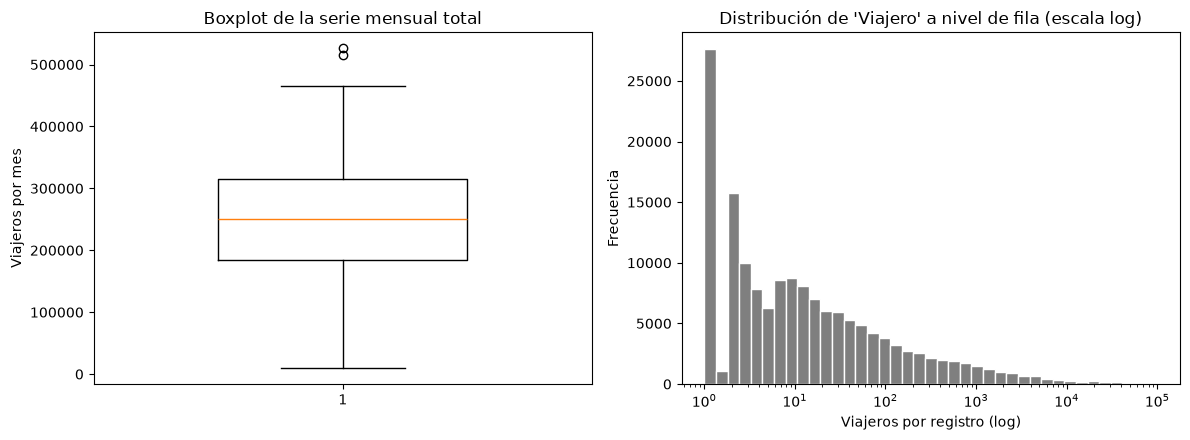

In [10]:
q1, q3 = serie.quantile([.25, .75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = serie[(serie < lo) | (serie > hi)]
print(f"Límites IQR de la serie mensual: [{lo:,.0f}, {hi:,.0f}]")
print(f"Atípicos mensuales por IQR: {len(outliers)}")
print(outliers.round(0))
print(f"\nMínimo de la serie (pandemia): {serie.min():,.0f} en {serie.idxmin().date()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(serie.values, vert=True, widths=0.5)
axes[0].set_title("Boxplot de la serie mensual total")
axes[0].set_ylabel("Viajeros por mes")
axes[1].hist(df["Viajero"], bins=np.logspace(0, 5, 40), color="tab:gray", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Distribución de 'Viajero' a nivel de fila (escala log)")
axes[1].set_xlabel("Viajeros por registro (log)")
axes[1].set_ylabel("Frecuencia")
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "eda_atipicos.png"), dpi=150)
plt.show()

**Interpretación (atípicos).** A nivel de fila, la distribución es de cola larga (escala log): domina el volumen un puñado de combinaciones grandes. En la **serie mensual**, el criterio IQR marca solo **2 atípicos, ambos altos**: **diciembre 2019 (515,820)** y **diciembre 2022 (526,190)**, que **no son errores** sino los picos estacionales de fin de año. Es notable que el **desplome pandémico (mínimo de 9,779 en abril 2020) no se marca como atípico por IQR** (el límite inferior es negativo): es un evento estructural, no un valor a depurar. Conclusión: no se elimina ningún atípico; todos son datos reales relevantes para el modelado.

## f. Cierre: estadísticas descriptivas por categoría

Tabla resumen de participación por vía y por tipo de viajero, y síntesis del EDA.

In [11]:
resumen_via = (df.groupby("Vía")["Viajero"].agg(["sum", "mean", "count"])
               .sort_values("sum", ascending=False))
resumen_via["% total"] = (resumen_via["sum"] / resumen_via["sum"].sum() * 100).round(1)
print("Por vía de ingreso:")
print(resumen_via.round(1))
print()
tipo = df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False)
print("Por tipo de viajero:")
print((tipo / tipo.sum() * 100).round(1).astype(str) + ' %')

Por vía de ingreso:
                  sum   mean   count  % total
Vía                                          
Terrestre  31995304.9  254.2  125873     61.2
Aérea      19063850.2  762.6   24999     36.5
Marítima    1228782.0  120.9   10164      2.4

Por tipo de viajero:
Tipo de Viajero
Turista          72.0 %
Excursionista    17.3 %
Viajero           8.6 %
Cruceristas       2.1 %
Name: Viajero, dtype: str


**Síntesis del EDA.**

- **Temporal (a):** serie mensual con estacionalidad fuerte (picos dic-ene y Semana Santa, valle en septiembre), crecimiento 2009-2019, colapso pandémico 2020-2021 y recuperación 2022+.
- **Países (b):** El Salvador, Estados Unidos y Honduras concentran el ingreso (Guatemala se excluye por ser retorno de residentes).
- **Regiones (c):** América del Centro (~71%) y del Norte (~18%) dominan; el ingreso es esencialmente regional.
- **Vías y fronteras (d):** terrestre (~61%) sobre aérea (~36%); La Aurora, Valle Nuevo y San Cristóbal son las fronteras clave.
- **Calidad (e):** sin nulos ni duplicados; decimales y ceros son legítimos; los únicos atípicos estadísticos son picos de diciembre, no errores.
- **Tipos:** Turista (72%) y Excursionista (17%) son consistentes en todo el período; 'Viajero' sufre el quiebre metodológico de 2023 (ver bloque 1).